In [2]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    StratifiedKFold
)
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

RANDOM_STATE = 42

sns.set_theme(style="whitegrid")

data = load_breast_cancer()

X = pd.DataFrame(
    data.data,
    columns=data.feature_names
)

y = pd.Series(
    data.target,
    name="target"
)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (569, 30)
y shape: (569,)


In [3]:
print("Target names:")

for idx, name in enumerate(data.target_names):
    print(f"{idx} -> {name}")

print("\nClass distribution:")

print(
    y.value_counts(normalize=True)
     .sort_index()
     .rename("proportion")
)

Target names:
0 -> malignant
1 -> benign

Class distribution:
target
0    0.372583
1    0.627417
Name: proportion, dtype: float64


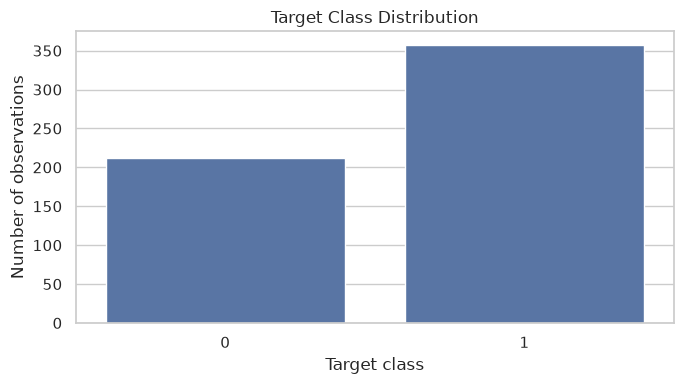

In [4]:
plt.figure(figsize=(7, 4))

ax = sns.countplot(x=y)

ax.set_title("Target Class Distribution")
ax.set_xlabel("Target class")
ax.set_ylabel("Number of observations")

plt.tight_layout()
plt.show()

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

print("\nTrain class distribution:")
print(y_train.value_counts(normalize=True).sort_index())

print("\nTest class distribution:")
print(y_test.value_counts(normalize=True).sort_index())

Train: (455, 30)
Test: (114, 30)

Train class distribution:
target
0    0.373626
1    0.626374
Name: proportion, dtype: float64

Test class distribution:
target
0    0.368421
1    0.631579
Name: proportion, dtype: float64


In [6]:
baseline_rf = RandomForestClassifier(
    random_state=RANDOM_STATE,
    n_jobs=-1
)

baseline_rf.fit(X_train, y_train)

baseline_pred = baseline_rf.predict(X_test)
baseline_proba = baseline_rf.predict_proba(X_test)[:, 1]

baseline_metrics = {
    "Accuracy": accuracy_score(y_test, baseline_pred),
    "Precision": precision_score(y_test, baseline_pred),
    "Recall": recall_score(y_test, baseline_pred),
    "F1": f1_score(y_test, baseline_pred),
    "ROC-AUC": roc_auc_score(y_test, baseline_proba),
}

baseline_metrics

{'Accuracy': 0.956140350877193,
 'Precision': 0.958904109589041,
 'Recall': 0.9722222222222222,
 'F1': 0.9655172413793104,
 'ROC-AUC': 0.9937169312169312}

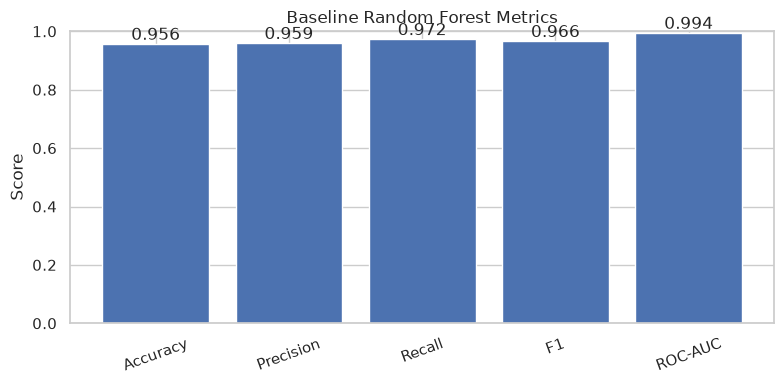

In [7]:
metric_names = list(baseline_metrics.keys())
metric_values = list(baseline_metrics.values())

plt.figure(figsize=(8, 4))

bars = plt.bar(metric_names, metric_values)

plt.ylim(0, 1)
plt.ylabel("Score")
plt.title("Baseline Random Forest Metrics")
plt.xticks(rotation=20)

for bar, value in zip(bars, metric_values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.015,
        f"{value:.3f}",
        ha="center"
    )

plt.tight_layout()
plt.show()

In [8]:
manual_depth_results = []
for depth in [3, 5, 10, 15]:
    model = RandomForestClassifier(
        max_depth=depth,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )
    model.fit(X_train, y_train)
    pred = model.predict(X_test)

    manual_depth_results.append({
        "max_depth":depth,
        "F1": f1_score(y_test, pred)
    })
manual_depth_df = pd.DataFrame(manual_depth_results)
manual_depth_df

,max_depth,F1
0,3,0.965517
1,5,0.965517
2,10,0.965517
3,15,0.965517
